# Daily Challenge: Custom Attention Mechanism & SMS Spam Classification

Week 12, Day 1

Welcome to the guided notebook for the *Custom Attention Mechanism & SMS Spam* daily challenge. All the **To-Do** cells have been completed and the notebook has been executed.

## Why are we doing this?
Modern NLP systems rely on attention. By rolling your own attention block and contrasting it with a pre-trained GPT-2 classifier, you will demystify how query/key/value flows shape downstream predictions on a real SMS spam dataset.

## Learning objectives
- Implement a custom scaled dot-product attention layer from scratch.
- Explain the respective roles of queries, keys, and values.
- Fine-tune GPT-2 for binary spam classification and compare it to a custom model.
- Evaluate both systems with accuracy, precision, recall, and F1.
- Reflect on trade-offs between transformer-based and lightweight attention models.

# Part 1: Setup & Data Loading

In [1]:
%pip install --quiet datasets evaluate transformers[sentencepiece]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
from datasets import Dataset
from datasets import load_dataset
import torch
torch.manual_seed(42)

In [3]:
# Load the UCI SMS Spam dataset from Hugging Face hub
DATA_PATH = 'hf://datasets/ucirvine/sms_spam/plain_text/train-00000-of-00001.parquet'
df = pd.read_parquet(DATA_PATH)          # load the parquet dataset into a pandas DataFrame
hf_dataset = Dataset.from_pandas(df)     # convert the DataFrame into a Hugging Face Dataset

TRAIN_START = 0
TRAIN_END = 4000   # use 4,000 samples for training
VAL_START = 4000   # begin validation split at 4,000
VAL_END = 5000     # stop validation split at 5,000

if None in (TRAIN_END, VAL_START, VAL_END):
    raise ValueError('Set TRAIN_END, VAL_START, and VAL_END according to the instructions.')

train_ds = hf_dataset.select(range(TRAIN_START, TRAIN_END))
val_ds = hf_dataset.select(range(VAL_START, VAL_END))
display(df.head())

print(df.shape, "| label 0 = ham (legit), 1 = spam")
print("Spam share - full: {:.1%} | train: {:.1%} | validation: {:.1%}".format(
    df['label'].mean(), sum(train_ds['label']) / len(train_ds), sum(val_ds['label']) / len(val_ds)))
print("Train:", train_ds, "\nValidation:", val_ds)

,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


(5574, 2) | label 0 = ham (legit), 1 = spam
Spam share - full: 13.4% | train: 13.4% | validation: 13.9%
Train: Dataset({
    features: ['sms', 'label'],
    num_rows: 4000
}) 
Validation: Dataset({
    features: ['sms', 'label'],
    num_rows: 1000
})


The dataset has 5,574 SMS, of which only **13.4% are spam** (139 spam messages among the 1,000 validation SMS). The classes are **imbalanced**: a model that always answers "ham" would already reach about 86% accuracy, which is why precision, recall and F1 on the spam class are essential.

# Part 2: Tokenization Setup
Initialize the GPT-2 tokenizer, set a padding token, and prepare batched tokenization for both splits.

> **Learning point**
> GPT-2 does not define a pad token. Reusing the EOS token keeps inputs aligned with how the model was pretrained.

In [4]:
from transformers import GPT2Tokenizer

MODEL_NAME = 'gpt2'  # you can also try 'gpt2-medium' or 'gpt2-large'
if MODEL_NAME is None:
    raise ValueError("Set MODEL_NAME to the pretrained checkpoint (e.g., 'gpt2').")

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default: reuse the EOS token
print("pad token:", repr(tokenizer.pad_token), "| id:", tokenizer.pad_token_id)

pad token: '<|endoftext|>' | id: 50256


In [5]:
TEXT_COLUMN = 'sms'             # the name of the text column in the dataset
PADDING_STRATEGY = 'max_length' # pad every message to MAX_SEQ_LEN
TRUNCATION_FLAG = True          # truncate sequences longer than MAX_SEQ_LEN
MAX_SEQ_LEN = 64                # SMS messages are short

for setting in (TEXT_COLUMN, PADDING_STRATEGY, TRUNCATION_FLAG, MAX_SEQ_LEN):
    if setting is None:
        raise ValueError('Complete TEXT_COLUMN, PADDING_STRATEGY, TRUNCATION_FLAG, and MAX_SEQ_LEN.')


def tokenize_fn(examples):
    return tokenizer(
        examples[TEXT_COLUMN],
        padding=PADDING_STRATEGY,
        truncation=TRUNCATION_FLAG,
        max_length=MAX_SEQ_LEN,
    )


train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok = val_ds.map(tokenize_fn, batched=True)

lengths = [len(tokenizer.encode(t)) for t in train_ds[TEXT_COLUMN]]
print(train_tok)
print(f"Token length of the SMS: median {int(pd.Series(lengths).median())}, 95th percentile {int(pd.Series(lengths).quantile(0.95))}, "
      f"truncated (> 64 tokens): {(pd.Series(lengths) > 64).mean():.1%}")

Dataset({
    features: ['sms', 'label', 'input_ids', 'attention_mask'],
    num_rows: 4000
})
Token length of the SMS: median 18, 95th percentile 52, truncated (> 64 tokens): 1.6%


# Part 3: Pre-trained GPT-2 Classifier
Load GPT-2 with a classification head suited for binary spam detection.

In [6]:
import torch
from transformers import GPT2ForSequenceClassification

NUM_LABELS = 2  # spam vs. ham: binary classification
if NUM_LABELS is None:
    raise ValueError('Set NUM_LABELS to 2 for binary classification.')

model = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    pad_token_id=tokenizer.eos_token_id,  # pad token id so the model knows where each sequence really ends
)
print(f"GPT-2 classifier: {model.num_parameters():,} parameters")

GPT-2 classifier: 124,441,344 parameters


> ⚠️ `GPT2ForSequenceClassification` adds a **new classification head** (a linear layer `score`, 768 → 2) on top of the pretrained GPT-2. This head is **randomly initialised**: the challenge pipeline evaluates the model directly, **without training it** on the spam data, so its predictions in Part 5 are essentially random. In the **bonus section** at the end we fine-tune GPT-2 to see its real potential.

# Part 4: Custom Attention Implementation
Build the simple attention layer, classifier, and data pipeline for the scratch model.

> **Learning point**
> Scaling the dot products by $1/\sqrt{d_k}$ keeps gradients stable and prevents the softmax from collapsing when embeddings grow. This operation is crucial for training deep attention models.

In [7]:
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


class Attention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.scale = embed_dim ** -0.5  # 1 / sqrt(d_k)

    def forward(self, query, key, value, mask=None):
        scores = torch.matmul(
            query,                   # (batch, seq_len, d)
            key.transpose(-2, -1),   # (batch, d, seq_len)
        ) * self.scale               # -> (batch, seq_len, seq_len): similarity of every token with every token
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)        # attention weights: each row sums to 1
        return torch.matmul(attn, value), attn  # weighted sum of the values: (batch, seq_len, d)


class SimpleAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attn = Attention(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embed = self.embedding(x)                          # (batch, seq_len, embed_dim)
        attn_output, _ = self.attn(embed, embed, embed)    # self-attention: query = key = value = embed
        pooled = attn_output.mean(dim=1)                   # mean over the sequence dimension
        return self.fc(pooled)                             # logits for the 2 classes

In [8]:
# Quick check of the attention layer on random data
q = k = v = torch.randn(2, 5, 8)
out, w = Attention(8)(q, k, v)
print("output:", out.shape, "| weights:", w.shape, "| rows sum to 1:", torch.allclose(w.sum(-1), torch.ones(2, 5)))

output: torch.Size([2, 5, 8]) | weights: torch.Size([2, 5, 5]) | rows sum to 1: True


> **Learning point**
> Tokenize once and reuse the same 64-token cap so both models receive comparable context windows.

In [9]:
ATTN_TEXT_COLUMN = 'sms'
ATTN_MAX_LEN = 64
if ATTN_TEXT_COLUMN is None or ATTN_MAX_LEN is None:
    raise ValueError('Complete ATTN_TEXT_COLUMN and ATTN_MAX_LEN.')


def preprocess_for_attention(example):
    tokens = tokenizer.encode(
        example[ATTN_TEXT_COLUMN],
        max_length=ATTN_MAX_LEN,
        truncation=True,
        padding='max_length',
    )
    return {'input_ids': tokens, 'label': example['label']}


train_ds_attn = train_ds.map(preprocess_for_attention)
val_ds_attn = val_ds.map(preprocess_for_attention)
print(train_ds_attn)

Dataset({
    features: ['sms', 'label', 'input_ids'],
    num_rows: 4000
})


In [10]:
class SMSDataset(Dataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'input_ids': torch.tensor(item['input_ids'], dtype=torch.long),
            'label': torch.tensor(item['label'], dtype=torch.long),
        }


TRAIN_DATA_FOR_LOADER = train_ds_attn
VAL_DATA_FOR_LOADER = val_ds_attn
if TRAIN_DATA_FOR_LOADER is None or VAL_DATA_FOR_LOADER is None:
    raise ValueError('Assign TRAIN_DATA_FOR_LOADER and VAL_DATA_FOR_LOADER before creating loaders.')


train_loader = DataLoader(SMSDataset(TRAIN_DATA_FOR_LOADER), batch_size=32, shuffle=True)
val_loader = DataLoader(SMSDataset(VAL_DATA_FOR_LOADER), batch_size=32)
batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})

{'input_ids': torch.Size([32, 64]), 'label': torch.Size([32])}


In [11]:
vocab_size = len(tokenizer)   # 50,257 tokens (the pad token reuses EOS, so nothing is added)
embed_dim = 64
num_classes = 2
learning_rate = 1e-3
if None in (vocab_size, num_classes, learning_rate):
    raise ValueError('Set vocab_size, num_classes, and learning_rate before training.')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
attn_model = SimpleAttentionClassifier(vocab_size, embed_dim, num_classes).to(device)
optimizer = torch.optim.Adam(attn_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
print(f"Custom attention model: {sum(p.numel() for p in attn_model.parameters()):,} parameters | device: {device}")

attn_model.train()
for batch in train_loader:
    inputs = batch['input_ids'].to(device)
    labels = batch['label'].to(device)
    optimizer.zero_grad()
    outputs = attn_model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

print('Custom Attention model trained on SMS dataset. Sample batch loss:', loss.item())

Custom attention model: 3,216,578 parameters | device: cpu


Custom Attention model trained on SMS dataset. Sample batch loss: 0.21862050890922546


# Part 5: Metrics & Evaluation
Load accuracy, precision, recall, and F1 from `evaluate`, then implement the shared `compute_metrics` helper.

In [12]:
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')
precision = evaluate.load('precision')
recall = evaluate.load('recall')
f1 = evaluate.load('f1')


def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy.compute(predictions=preds, references=labels)['accuracy'],
        'precision': precision.compute(predictions=preds, references=labels, zero_division=0)['precision'],
        'recall': recall.compute(predictions=preds, references=labels)['recall'],
        'f1': f1.compute(predictions=preds, references=labels)['f1'],
    }

# precision, recall and F1 are computed for the positive class (1 = spam)

> **Learning point**
> Use the same helper dictionary pattern for both GPT-2 and the custom model so you can compare metrics side by side.

In [13]:
print("\n📊 Evaluating GPT-2 Model...")
gpt2_preds = []
gpt2_labels = []
model.eval()
for ex in val_tok:
    inputs = torch.tensor(ex['input_ids']).unsqueeze(0).to(model.device)
    with torch.no_grad():
        logits = model(inputs).logits
    pred = torch.argmax(logits, dim=-1).cpu().item()
    gpt2_preds.append(pred)
    gpt2_labels.append(ex['label'])


gpt2_metrics = {
    'accuracy': accuracy.compute(predictions=gpt2_preds, references=gpt2_labels)['accuracy'],
    'precision': precision.compute(predictions=gpt2_preds, references=gpt2_labels, zero_division=0)['precision'],
    'recall': recall.compute(predictions=gpt2_preds, references=gpt2_labels)['recall'],
    'f1': f1.compute(predictions=gpt2_preds, references=gpt2_labels)['f1'],
}
print('GPT-2 Metrics:', gpt2_metrics)
print(f"Messages predicted as spam: {sum(gpt2_preds)} / {len(gpt2_preds)} (actual spam: {sum(gpt2_labels)})")


📊 Evaluating GPT-2 Model...


GPT-2 Metrics: {'accuracy': 0.858, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
Messages predicted as spam: 3 / 1000 (actual spam: 139)


In [14]:
print("\n📊 Evaluating Custom Attention Model...")
attn_preds = []
attn_labels = []
attn_model.eval()
for batch in val_loader:
    inputs = batch['input_ids'].to(device)
    labels = batch['label'].to(device)
    with torch.no_grad():
        outputs = attn_model(inputs)
        preds = torch.argmax(outputs, dim=1)
    attn_preds.extend(preds.cpu().tolist())
    attn_labels.extend(labels.cpu().tolist())


attn_metrics = {
    'accuracy': accuracy.compute(predictions=attn_preds, references=attn_labels)['accuracy'],
    'precision': precision.compute(predictions=attn_preds, references=attn_labels, zero_division=0)['precision'],
    'recall': recall.compute(predictions=attn_preds, references=attn_labels)['recall'],
    'f1': f1.compute(predictions=attn_preds, references=attn_labels)['f1'],
}
print('Attention Model Metrics:', attn_metrics)
print(f"Messages predicted as spam: {sum(attn_preds)} / {len(attn_preds)} (actual spam: {sum(attn_labels)})")


📊 Evaluating Custom Attention Model...
Attention Model Metrics: {'accuracy': 0.862, 'precision': 0.5238095238095238, 'recall': 0.07913669064748201, 'f1': 0.1375}
Messages predicted as spam: 21 / 1000 (actual spam: 139)


In [15]:
results = pd.DataFrame({'GPT-2 (head not trained)': gpt2_metrics, 'Custom attention (1 epoch)': attn_metrics}).T
display(results.style.format('{:.4f}'))

,accuracy,precision,recall,f1
GPT-2 (head not trained),0.8580,0.0000,0.0000,0.0000
Custom attention (1 epoch),0.8620,0.5238,0.0791,0.1375


## Bonus: training both models properly

The challenge pipeline gives an unfair comparison: GPT-2's classification head is never trained, and the custom model only sees the training data once. To compare the two approaches fairly, we:
1. **fine-tune GPT-2** for 1 epoch on the 4,000 training SMS (the whole network, small learning rate 2e-5), using the attention mask so that padding is ignored;
2. train the **custom attention model for 10 epochs**, with a version that **masks the padding tokens** in the attention and in the mean pooling (with `padding='max_length'`, most of the 64 positions are EOS padding tokens, which dilute the mean).

In [16]:
import time
from torch.utils.data import TensorDataset

def to_tensors(ds_tok):
    return (torch.tensor(ds_tok['input_ids']), torch.tensor(ds_tok['attention_mask']), torch.tensor(ds_tok['label']))

train_t, val_t = to_tensors(train_tok), to_tensors(val_tok)
gpt2_train_loader = DataLoader(TensorDataset(*train_t), batch_size=16, shuffle=True)
gpt2_val_loader = DataLoader(TensorDataset(*val_t), batch_size=64)

torch.manual_seed(42)
ft_model = GPT2ForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, pad_token_id=tokenizer.eos_token_id).to(device)
ft_optimizer = torch.optim.AdamW(ft_model.parameters(), lr=2e-5)

t0 = time.time()
ft_model.train()
for step, (ids, mask, labels) in enumerate(gpt2_train_loader, 1):
    ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
    out = ft_model(input_ids=ids, attention_mask=mask, labels=labels)
    ft_optimizer.zero_grad()
    out.loss.backward()
    ft_optimizer.step()
    if step % 50 == 0:
        print(f"step {step}/{len(gpt2_train_loader)} | loss {out.loss.item():.4f} | {time.time() - t0:.0f}s")
print(f"GPT-2 fine-tuned for 1 epoch in {(time.time() - t0) / 60:.1f} min")

ft_model.eval()
ft_logits = []
with torch.no_grad():
    for ids, mask, labels in gpt2_val_loader:
        ft_logits.append(ft_model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits.cpu().numpy())
ft_metrics = compute_metrics((np.concatenate(ft_logits), np.array(val_tok['label'])))
print("Fine-tuned GPT-2 metrics:", ft_metrics)

step 50/250 | loss 0.1404 | 102s


step 100/250 | loss 0.0373 | 192s


step 150/250 | loss 0.0843 | 282s


step 200/250 | loss 0.0202 | 371s


step 250/250 | loss 0.0031 | 460s
GPT-2 fine-tuned for 1 epoch in 7.7 min


Fine-tuned GPT-2 metrics: {'accuracy': 0.989, 'precision': 0.9776119402985075, 'recall': 0.9424460431654677, 'f1': 0.9597069597069597}


In [17]:
class MaskedAttentionClassifier(nn.Module):
    """Same architecture, but padding tokens are ignored by the attention and by the mean pooling."""
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.attn = Attention(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x, pad_mask):
        embed = self.embedding(x)
        attn_output, _ = self.attn(embed, embed, embed, mask=pad_mask.unsqueeze(1))  # keys at padding positions masked
        m = pad_mask.unsqueeze(-1).float()
        pooled = (attn_output * m).sum(1) / m.sum(1).clamp(min=1)                    # mean over real tokens only
        return self.fc(pooled)

masked_train_loader = DataLoader(TensorDataset(*train_t), batch_size=32, shuffle=True)

def evaluate_masked(m):
    m.eval()
    logits = []
    with torch.no_grad():
        for ids, mask, labels in gpt2_val_loader:
            logits.append(m(ids.to(device), mask.to(device)).cpu().numpy())
    return compute_metrics((np.concatenate(logits), np.array(val_tok['label'])))

torch.manual_seed(42)
attn10 = MaskedAttentionClassifier(vocab_size, embed_dim, num_classes).to(device)
opt10 = torch.optim.Adam(attn10.parameters(), lr=1e-3)
history10 = []
for epoch in range(1, 11):
    attn10.train()
    total = 0
    for ids, mask, labels in masked_train_loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        opt10.zero_grad()
        loss = criterion(attn10(ids, mask), labels)
        loss.backward()
        opt10.step()
        total += loss.item() * len(ids)
    metrics = evaluate_masked(attn10)
    history10.append({'epoch': epoch, 'train loss': total / len(masked_train_loader.dataset), **metrics})
    print(f"epoch {epoch:2d} | train loss {history10[-1]['train loss']:.4f} | val acc {metrics['accuracy']:.4f} | val F1 {metrics['f1']:.4f}")
attn10_metrics = history10[-1]

epoch  1 | train loss 0.4792 | val acc 0.8630 | val F1 0.0420


epoch  2 | train loss 0.2601 | val acc 0.8910 | val F1 0.3550


epoch  3 | train loss 0.1611 | val acc 0.9520 | val F1 0.7913


epoch  4 | train loss 0.0994 | val acc 0.9690 | val F1 0.8745


epoch  5 | train loss 0.0657 | val acc 0.9810 | val F1 0.9266


epoch  6 | train loss 0.0470 | val acc 0.9850 | val F1 0.9434


epoch  7 | train loss 0.0356 | val acc 0.9880 | val F1 0.9549


epoch  8 | train loss 0.0278 | val acc 0.9880 | val F1 0.9549


epoch  9 | train loss 0.0223 | val acc 0.9880 | val F1 0.9549


epoch 10 | train loss 0.0181 | val acc 0.9890 | val F1 0.9588


,accuracy,precision,recall,f1
"GPT-2, head not trained (challenge pipeline)",0.8580,0.0000,0.0000,0.0000
"Custom attention, 1 epoch (challenge pipeline)",0.8620,0.5238,0.0791,0.1375
"Custom attention, masked, 10 epochs (bonus)",0.9890,1.0000,0.9209,0.9588
"GPT-2 fine-tuned, 1 epoch (bonus)",0.9890,0.9776,0.9424,0.9597


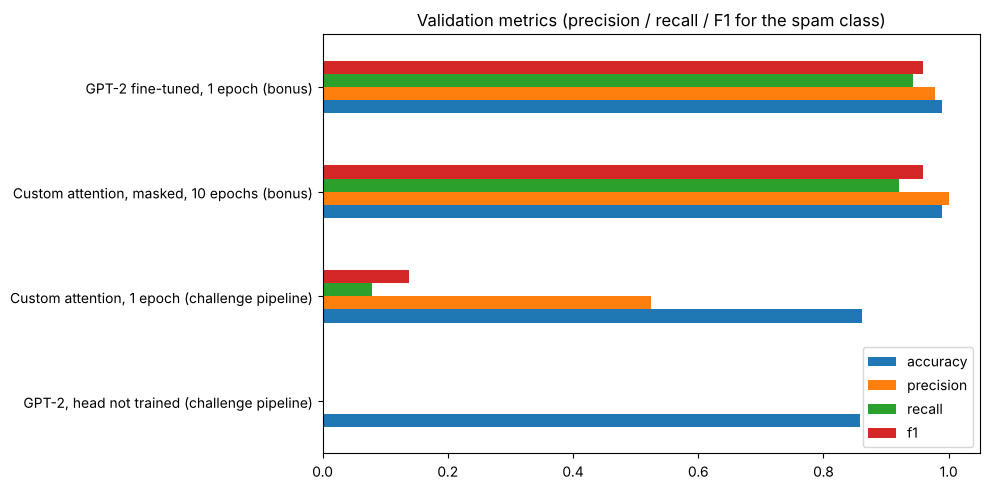

In [18]:
final = pd.DataFrame({
    'GPT-2, head not trained (challenge pipeline)': gpt2_metrics,
    'Custom attention, 1 epoch (challenge pipeline)': attn_metrics,
    'Custom attention, masked, 10 epochs (bonus)': {k: attn10_metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1']},
    'GPT-2 fine-tuned, 1 epoch (bonus)': ft_metrics,
}).T
display(final.style.format('{:.4f}'))

final[['accuracy', 'precision', 'recall', 'f1']].plot(kind='barh', figsize=(10, 5))
import matplotlib.pyplot as plt
plt.xlim(0, 1.05); plt.title('Validation metrics (precision / recall / F1 for the spam class)')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

# Part 6: Reflection Questions

### 1. What are the roles of query, key, and value in the attention mechanism?

Each token is projected into three vectors. The **query** represents what the current token is *looking for* in the rest of the sequence ("which words are relevant to understand me?"). The **keys** describe what each token *offers*, like a label used to be found: the dot product query·key measures how well a token matches the query, and after the softmax these scores become the **attention weights**. The **values** carry the actual *content* of each token: the output for a position is the weighted average of all the values, so the tokens with the highest weights contribute most to the new, context-aware representation. In our simple layer, query = key = value = the embedding (self-attention without learned projections); real Transformers learn three separate projection matrices W_Q, W_K, W_V.

### 2. Why do we use a scaling factor (e.g., 1/√d_k) in the dot-product attention?

The dot product of two random vectors of dimension d_k is a sum of d_k terms, so its variance grows proportionally to d_k: with large embeddings the scores become very large in absolute value. The softmax of very large scores is extremely peaked (almost one-hot): one token gets almost all the weight and the gradients of the others become close to zero, so training becomes slow and unstable. Dividing the scores by √d_k brings their variance back to about 1, which keeps the softmax in a range where it is smooth and the gradients flow well.

### 3. How does self-attention differ from traditional sequence models like RNNs?

- **Sequential vs. parallel:** an RNN reads the tokens one by one, each step depending on the previous hidden state, so it cannot be parallelised over the sequence; self-attention computes the interactions between all pairs of tokens at once with matrix multiplications, which GPUs process in parallel.
- **Long-range dependencies:** in an RNN, information from an early word must travel through every intermediate step and tends to fade (vanishing gradients, even with LSTMs); in self-attention any token is directly connected to any other token (path length 1), so distant dependencies are captured easily.
- **Computational efficiency:** attention costs O(n²) in memory and time with respect to the sequence length n (every pair of tokens), whereas an RNN is O(n) but sequential; for typical sentence lengths attention is much faster in practice, but it becomes expensive for very long documents.
- **Training dynamics:** Transformers train faster and more stably on large datasets (no backpropagation through time, residual connections and normalisation), which is what made large pretrained models like GPT possible; they do need positional encodings because attention alone does not know the order of the tokens.

### 4. Performance analysis

| Model (validation, 1,000 SMS, 139 spam) | Accuracy | Precision (spam) | Recall (spam) | F1 (spam) |
|---|---|---|---|---|
| GPT-2, classification head not trained (challenge pipeline) | 0.858 | 0.000 | 0.000 | 0.000 |
| Custom attention, 1 epoch (challenge pipeline) | 0.862 | 0.524 | 0.079 | 0.138 |
| Custom attention, padding masked, 10 epochs (bonus) | **0.989** | **1.000** | 0.921 | 0.959 |
| GPT-2 fine-tuned, 1 epoch (bonus) | **0.989** | 0.978 | **0.942** | **0.960** |

**Which model performed better and why?** In the challenge pipeline as written, neither model really works, and accuracy is misleading. **GPT-2** reaches 85.8% accuracy only because it predicts "ham" almost every time (3 messages predicted as spam, none of them correct): its classification head is randomly initialised and was **never trained**, so precision, recall and F1 are 0. The pretrained GPT-2 knows the language, but nothing told it what "spam" means. The **custom attention model**, trained for a single epoch, is slightly better (86.2%) but finds only 11 of the 139 spam messages (recall 7.9%): one pass over 4,000 SMS is not enough, and its mean pooling is dominated by the padding tokens (an SMS has a median of 18 tokens out of 64 positions). Once both models are **trained properly** (bonus), both reach about **98.9% accuracy and F1 ≈ 0.96**. Fine-tuned GPT-2 has a slightly better recall (it catches 131 of the 139 spams), while the custom model, after 10 epochs and with the padding masked, makes no false alarms at all (precision 1.0) but misses a few more spams (128 found).

**Trade-offs and improvements:** GPT-2 brings knowledge from pretraining, so a single epoch with a small learning rate is enough, and it understands context, misspellings and unseen wordings better. But it has **124 million parameters**: fine-tuning took about 8 minutes on a CPU for one epoch and it is slower and heavier at prediction time. The custom model is about **40 times smaller** (3.2 million parameters, almost all in the embedding table), trains in seconds per epoch and works very well here because spam SMS are short and have very characteristic words ("free", "win", "claim", "call now", phone numbers and prices), but it learns everything from only 4,000 messages and has no notion of word order (no positional encoding). To improve the custom attention classifier: (1) **mask the padding** in the attention and the pooling (already done in the bonus version, a big gain); (2) train for **several epochs** with early stopping on the validation F1; (3) add **learned query/key/value projections**, **multiple heads**, **positional embeddings** and a feed-forward layer with residual connections and layer normalisation, i.e. a small Transformer encoder block; (4) handle the class imbalance with **class weights** in the loss or by tuning the decision threshold, to raise the recall on spam; (5) initialise the embeddings with pretrained word vectors.